In [51]:
from transformers import SegformerForSemanticSegmentation
from segformer_crossattention_wrapper import *
from segformer_crossattention_wrapperv2 import *
from utils import *
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
model = SegformerCrossAttentionWrapper(segformer_name='nvidia/mit-b5', mode='dct')
model = model.to(device)
cp_path = './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_dct_no_amp.pth'

checkpoint = torch.load(cp_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

# target_val_loaders[target_name] = utils.get_dataloader_from_dataset(target_path, target_name, 'val', batch_size=1, shuffle=False)

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<All keys matched successfully>

In [3]:
# target_loader = utils.get_dataloader_from_dataset('./cityscapes', 'cityscapes', 'val', batch_size=1, shuffle=False)
target_loader = utils.get_dataloader_from_dataset('./cityscapes', 'cityscapes', 'val', batch_size=1, shuffle=False)

Use cityscapes as the target dataset


In [17]:
def visualize_cross_attention(model, images, DEVICE, layer_indices=None, head_indices=None, upsample=True):
    """
    images: Tensor [B, 3, H, W]
    model: SegformerCrossAttentionWrapper
    layer_indices: Liste von Layern, die visualisiert werden sollen (0-3)
    head_indices: Liste von Heads pro Layer, die visualisiert werden sollen
    upsample: Ob die Attention auf Bildgröße hochskaliert werden soll
    """
    model.eval()
    images = images.to(DEVICE)

    with torch.no_grad():
        logits, attentions = model(images, return_attention=True)

    num_layers = len(attentions)
    B, _, H_img, W_img = images.shape

    layer_indices = layer_indices if layer_indices is not None else list(range(num_layers))
    head_indices = head_indices if head_indices is not None else None  # alle Heads

    for l_idx in layer_indices:
        attn_layer = attentions[l_idx]  # [B, num_heads, Nq, Nk]
        num_heads = attn_layer.shape[1]
        Nq, Nk = attn_layer.shape[2], attn_layer.shape[3]
        heads_to_plot = head_indices if head_indices is not None else list(range(num_heads))

        # Berechne Feature-Map-Shape aus Nk (Keys)
        # Achtung: Flattened aus H_feat * W_feat
        H_feat = W_feat = int(Nk ** 0.5) if (Nk ** 0.5).is_integer() else None

        for h_idx in heads_to_plot:
            attn = attn_layer[0, h_idx]  # Shape [Nq, Nk]

            # mitteln über Queries, um 2D Map zu bekommen
            attn_map = attn.mean(0)  # [Nk]

            # Falls Key-Feature nicht quadratisch ist, einfach 1D-Map belassen und hochskalieren
            if H_feat is not None:
                attn_map_2d = attn_map.view(H_feat, W_feat)
            else:
                attn_map_2d = attn_map.unsqueeze(0).unsqueeze(0)  # [1,1,Nk]

            if upsample:
                if H_feat is not None:
                    attn_map_2d = F.interpolate(
                        attn_map_2d.unsqueeze(0).unsqueeze(0), 
                        size=(H_img, W_img), 
                        mode='bilinear', 
                        align_corners=False
                    ).squeeze().cpu().numpy()
                else:
                    attn_map_2d = F.interpolate(
                        attn_map_2d, size=(H_img*W_img,), mode='linear'
                    ).view(H_img, W_img).cpu().numpy()
            else:
                if H_feat is not None:
                    attn_map_2d = attn_map_2d.cpu().numpy()
                else:
                    attn_map_2d = attn_map.cpu().numpy()

            # Bild anzeigen
            fig, ax = plt.subplots(1,2, figsize=(10,5))
            img_vis = images[0].permute(1,2,0).cpu().numpy() * 0.225 + 0.45  # ungefähr Normalisierung rückgängig
            ax[0].imshow(img_vis)
            ax[0].set_title(f"Input Image")
            ax[0].axis('off')

            ax[1].imshow(img_vis)
            ax[1].imshow(attn_map_2d, cmap='hot', alpha=0.6)
            ax[1].set_title(f"Layer {l_idx}, Head {h_idx} Attention")
            ax[1].axis('off')

            plt.show()

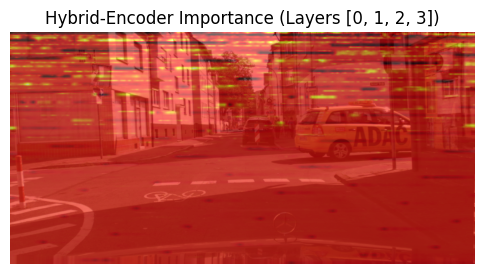

In [5]:
def visualize_hybrid_importance(model, images, DEVICE, layer_indices=None, upsample=True, alpha=0.6):
    """
    Zeigt die mittlere Cross-Attention pro Layer auf dem Input-Bild, um die Wichtigkeit des Hybrid-Encoders zu visualisieren.
    
    images: Tensor [B, 3, H, W]
    model: SegformerCrossAttentionWrapper
    layer_indices: Liste von Layern, die visualisiert werden sollen (0-3)
    upsample: Ob die Attention auf Bildgröße hochskaliert werden soll
    alpha: Transparenz der Heatmap
    """
    model.eval()
    images = images.to(DEVICE)

    with torch.no_grad():
        logits, attentions = model(images, return_attention=True)

    num_layers = len(attentions)
    B, _, H_img, W_img = images.shape

    layer_indices = layer_indices if layer_indices is not None else list(range(num_layers))

    # Bild für Anzeige vorbereiten
    img_vis = images[0].permute(1,2,0).cpu().numpy()
    img_vis = img_vis * 0.225 + 0.45   # Normalisierung rückgängig
    img_vis = img_vis.clip(0,1)        # Clip auf [0,1] für imshow

    # Mittlere Attention über ausgewählte Layer
    attn_combined = 0
    for l_idx in layer_indices:
        attn_layer = attentions[l_idx][0]  # Batch 0, Shape [num_heads, Nq, Nk]
        attn_mean_head = attn_layer.mean(0)  # mitteln über Heads, Shape [Nq, Nk]
        attn_map = attn_mean_head.mean(0)    # mitteln über Queries, Shape [Nk]

        side_len = int(attn_map.shape[0] ** 0.5)
        attn_map_2d = attn_map[:side_len**2].reshape(side_len, side_len)

        if upsample:
            attn_map_2d = F.interpolate(
                attn_map_2d.unsqueeze(0).unsqueeze(0),
                size=(H_img, W_img),
                mode='bilinear',
                align_corners=False
            ).squeeze().cpu().numpy()

        attn_combined += attn_map_2d

    # Durchschnitt über Layer
    attn_combined /= len(layer_indices)

    # Darstellung
    plt.figure(figsize=(6,6))
    plt.imshow(img_vis)
    plt.imshow(attn_combined, cmap='hot', alpha=alpha)
    plt.axis('off')
    plt.title(f'Hybrid-Encoder Importance (Layers {layer_indices})')
    plt.show()


# Beispiel-Aufruf:
images, _ = next(iter(target_loader))
visualize_hybrid_importance(model, images, device, layer_indices=[0,1,2,3])

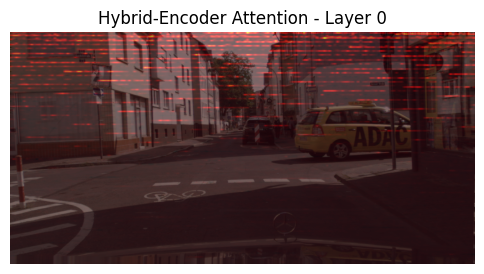

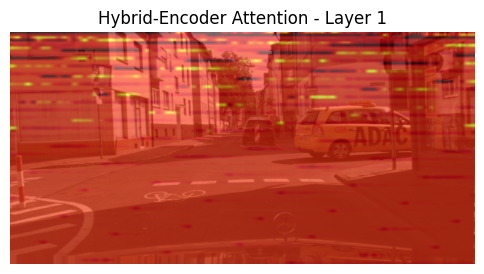

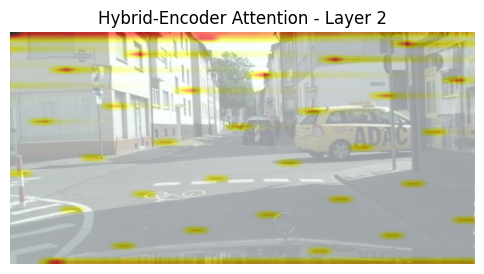

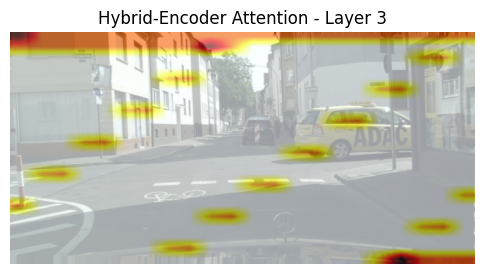

In [6]:
A

/tmp/ipykernel_156789/142849203.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.9,1])


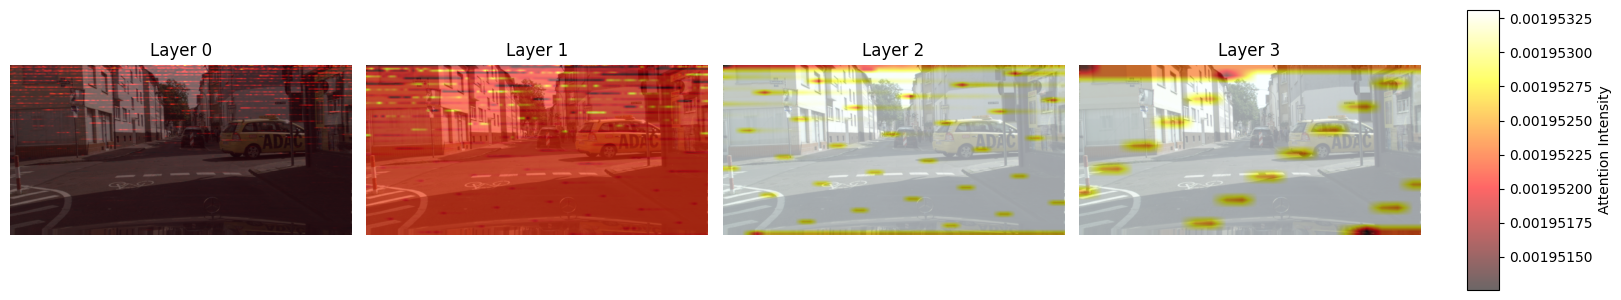

In [22]:
def visualize_hybrid_attention_compact(model, images, DEVICE, upsample=True, alpha=0.6):
    """
    Zeigt die Cross-Attention pro Layer kompakt nebeneinander mit Farblegende.
    """
    model.eval()
    images = images.to(DEVICE)

    with torch.no_grad():
        logits, attentions = model(images, return_attention=True)

    B, _, H_img, W_img = images.shape
    num_layers = len(attentions)

    # Bild vorbereiten
    img_vis = images[0].permute(1,2,0).cpu().numpy()
    img_vis = img_vis * 0.225 + 0.45
    img_vis = img_vis.clip(0,1)

    fig, axes = plt.subplots(1, num_layers, figsize=(4*num_layers,4))
    if num_layers == 1:
        axes = [axes]

    for l_idx, ax in enumerate(axes):
        attn_layer = attentions[l_idx][0]  # Batch 0, Shape [num_heads, Nq, Nk]
        attn_map = attn_layer.mean(0).mean(0)  # mitteln über Heads und Queries

        side_len = int(attn_map.shape[0] ** 0.5)
        attn_map_2d = attn_map[:side_len**2].reshape(side_len, side_len)

        if upsample:
            attn_map_2d = F.interpolate(
                attn_map_2d.unsqueeze(0).unsqueeze(0),
                size=(H_img, W_img),
                mode='bilinear',
                align_corners=False
            ).squeeze().cpu().numpy()

        ax.imshow(img_vis)
        im = ax.imshow(attn_map_2d, cmap='hot', alpha=alpha)
        ax.axis('off')
        ax.set_title(f'Layer {l_idx}')

    # Farblegende rechts hinzufügen
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Attention Intensity')

    plt.tight_layout(rect=[0,0,0.9,1])
    plt.show()


# Aufruf:
images, _ = next(iter(target_loader))
visualize_hybrid_attention_compact(model, images, device)

In [4]:
loader_iter = iter(target_loader)
images_list = []

# Wir nehmen so lange Batches, bis wir 3 Bilder haben
while len(images_list) < 3:
    images, _ = next(loader_iter)  # nächstes Batch
    for img in images:
        images_list.append(img)
        if len(images_list) == 3:
            break

# images_list enthält nun die ersten 3 Bilder
# Um sie zu visualisieren:
# for i, img in enumerate(images_list):
#     visualize_hybrid_attention_compact(model, img.unsqueeze(0), device)

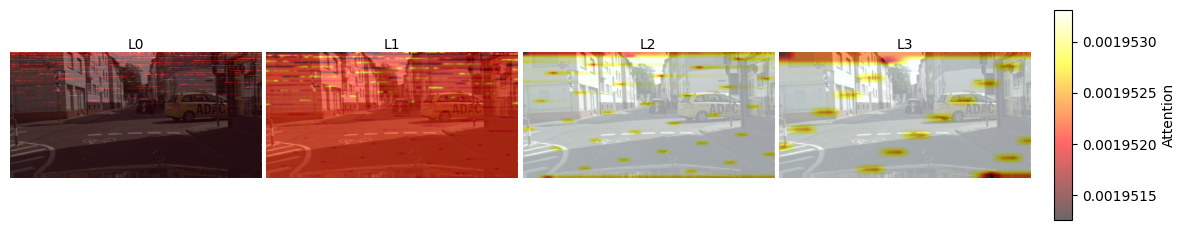

In [26]:
def visualize_hybrid_attention_compact(model, images, DEVICE, upsample=True, alpha=0.6):
    """
    Zeigt die Cross-Attention pro Layer kompakt nebeneinander mit Farblegende.
    """
    model.eval()
    images = images.to(DEVICE)

    with torch.no_grad():
        logits, attentions = model(images, return_attention=True)

    B, _, H_img, W_img = images.shape
    num_layers = len(attentions)

    # Bild vorbereiten
    img_vis = images[0].permute(1,2,0).cpu().numpy()
    img_vis = img_vis * 0.225 + 0.45
    img_vis = img_vis.clip(0,1)

    # Kompaktere Subplots mit weniger Abstand
    fig, axes = plt.subplots(1, num_layers, figsize=(3*num_layers, 3))
    if num_layers == 1:
        axes = [axes]

    for l_idx, ax in enumerate(axes):
        attn_layer = attentions[l_idx][0]  # Batch 0, Shape [num_heads, Nq, Nk]
        attn_map = attn_layer.mean(0).mean(0)  # mitteln über Heads und Queries

        side_len = int(attn_map.shape[0] ** 0.5)
        attn_map_2d = attn_map[:side_len**2].reshape(side_len, side_len)

        if upsample:
            attn_map_2d = F.interpolate(
                attn_map_2d.unsqueeze(0).unsqueeze(0),
                size=(H_img, W_img),
                mode='bilinear',
                align_corners=False
            ).squeeze().cpu().numpy()

        ax.imshow(img_vis)
        im = ax.imshow(attn_map_2d, cmap='hot', alpha=alpha)
        ax.axis('off')
        ax.set_title(f'L{l_idx}', fontsize=10, pad=2)  # Kürzerer Titel

    # Farblegende kompakt platzieren
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # Dünnere Farblegende
    fig.colorbar(im, cax=cbar_ax, label='Attention')

    # Minimale Abstände
    plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0.05, right=0.9, top=0.95, bottom=0.05)
    plt.show()


# Aufruf:
# images, _ = next(iter(target_loader))
# visualize_hybrid_attention_compact(model, images, device)

In [14]:
loader_iter = iter(target_loader)
images_list = []

# Wir nehmen so lange Batches, bis wir 3 Bilder haben
while len(images_list) < 3:
    images, _ = next(loader_iter)  # nächstes Batch
    for img in images:
        images_list.append(img)
        if len(images_list) == 3:
            break

# # images_list enthält nun die ersten 3 Bilder
# # Um sie zu visualisieren:
# for i, img in enumerate(images_list):
#     visualize_hybrid_attention_compact(model, img.unsqueeze(0), device)

Figure gespeichert unter: hybrid_attention_compact.png


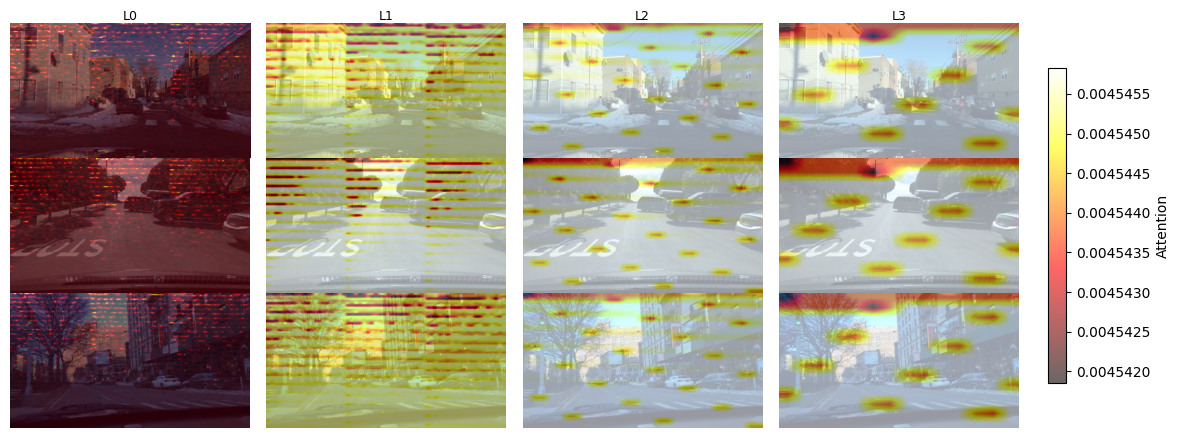

In [15]:
def visualize_hybrid_attention_multi_lowmem_compact_paper(model, images, DEVICE, upsample=True, alpha=0.6, save_path=None):
    """
    Zeigt Cross-Attention für mehrere Bilder extrem kompakt (vertikal dicht) für Paper.
    Optional: direkt als Bild speichern.
    """
    model.eval()
    num_layers = None
    num_images = images.shape[0]

    fig, axes = None, None

    for i in range(num_images):
        img = images[i].unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            logits, attentions = model(img, return_attention=True)

        if num_layers is None:
            num_layers = len(attentions)
            fig, axes = plt.subplots(num_images, num_layers, figsize=(3*num_layers, 1.5*num_images))
            if num_images == 1:
                axes = [axes]
            if num_layers == 1:
                axes = [[ax] for ax in axes]

        img_vis = img[0].permute(1,2,0).cpu().numpy()
        img_vis = img_vis * 0.225 + 0.45
        img_vis = img_vis.clip(0,1)
        H_img, W_img = img_vis.shape[:2]

        for l_idx in range(num_layers):
            ax = axes[i][l_idx]
            attn_layer = attentions[l_idx][0]
            attn_map = attn_layer.mean(0).mean(0).cpu()

            side_len = int(attn_map.shape[0] ** 0.5)
            attn_map_2d = attn_map[:side_len**2].reshape(side_len, side_len).unsqueeze(0).unsqueeze(0)

            if upsample:
                attn_map_2d = F.interpolate(
                    attn_map_2d, size=(H_img, W_img), mode='bilinear', align_corners=False
                ).squeeze().numpy()

            ax.imshow(img_vis)
            im = ax.imshow(attn_map_2d, cmap='hot', alpha=alpha)
            ax.axis('off')
            if i == 0:
                ax.set_title(f'L{l_idx}', fontsize=9, pad=1)

        del img, logits, attentions
        torch.cuda.empty_cache()

    # Gemeinsame Farblegende
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Attention')

    # Extrem kompakt
    plt.subplots_adjust(wspace=0.02, hspace=0, left=0.05, right=0.9, top=0.95, bottom=0.05)

    # Speichern, falls Pfad angegeben
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure gespeichert unter: {save_path}")

    plt.show()


images_tensor = torch.stack(images_list)
visualize_hybrid_attention_multi_lowmem_compact_paper(
    model, images_tensor, device,
    save_path="hybrid_attention_compact.png"
)

Figure gespeichert unter: hybrid_attention_compact.png


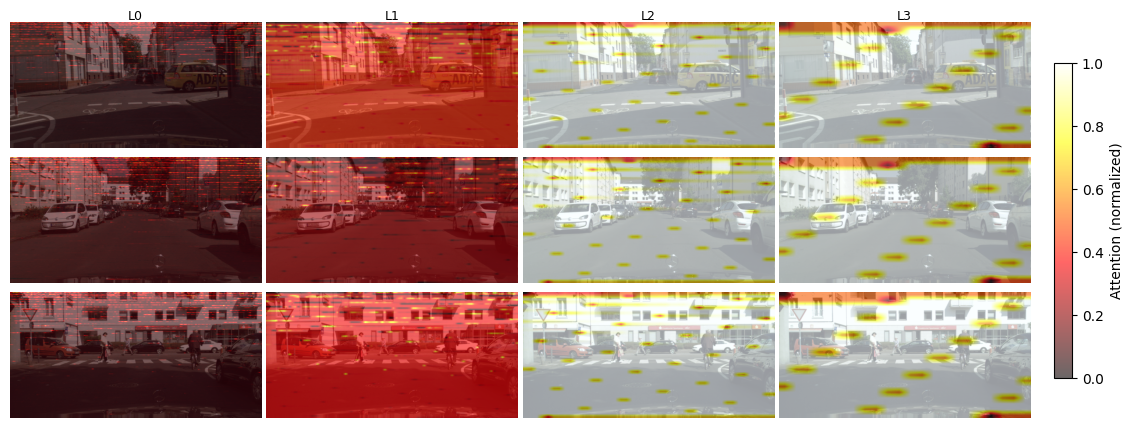

In [10]:
def visualize_hybrid_attention_multi_lowmem_compact_paper(
    model, images, DEVICE, upsample=True, alpha=0.6, save_path=None, gamma=1.0
):
    """
    Zeigt Cross-Attention für mehrere Bilder extrem kompakt (vertikal dicht) für Paper.
    Optional: direkt als Bild speichern. Werte werden pro Layer normalisiert und optional
    gammakorrigiert.
    """
    model.eval()
    num_layers = None
    num_images = images.shape[0]

    fig, axes = None, None

    for i in range(num_images):
        img = images[i].unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            logits, attentions = model(img, return_attention=True)

        if num_layers is None:
            num_layers = len(attentions)
            fig, axes = plt.subplots(num_images, num_layers, figsize=(3*num_layers, 1.5*num_images))
            if num_images == 1:
                axes = [axes]
            if num_layers == 1:
                axes = [[ax] for ax in axes]

        img_vis = img[0].permute(1,2,0).cpu().numpy()
        img_vis = img_vis * 0.225 + 0.45
        img_vis = img_vis.clip(0,1)
        H_img, W_img = img_vis.shape[:2]

        for l_idx in range(num_layers):
            ax = axes[i][l_idx]
            attn_layer = attentions[l_idx][0]
            attn_map = attn_layer.mean(0).mean(0).cpu()

            side_len = int(attn_map.shape[0] ** 0.5)
            attn_map_2d = attn_map[:side_len**2].reshape(side_len, side_len).unsqueeze(0).unsqueeze(0)

            if upsample:
                attn_map_2d = F.interpolate(
                    attn_map_2d, size=(H_img, W_img), mode='bilinear', align_corners=False
                ).squeeze().numpy()

            # Normalisierung auf [0,1] und optional Gamma-Korrektur
            attn_map_2d = attn_map_2d - attn_map_2d.min()
            if attn_map_2d.max() > 0:
                attn_map_2d = attn_map_2d / attn_map_2d.max()
            attn_map_2d = attn_map_2d ** gamma

            ax.imshow(img_vis)
            im = ax.imshow(attn_map_2d, cmap='hot', alpha=alpha)
            ax.axis('off')
            if i == 0:
                ax.set_title(f'L{l_idx}', fontsize=9, pad=1)

        del img, logits, attentions
        torch.cuda.empty_cache()

    # Gemeinsame Farblegende
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Attention (normalized)')

    # Extrem kompakt
    plt.subplots_adjust(wspace=0.02, hspace=0, left=0.05, right=0.9, top=0.95, bottom=0.05)

    # Speichern, falls Pfad angegeben
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure gespeichert unter: {save_path}")

    plt.show()


images_tensor = torch.stack(images_list)
visualize_hybrid_attention_multi_lowmem_compact_paper(
    model, images_tensor, device,
    save_path="hybrid_attention_compact.png"
)

Figure gespeichert unter: heads_layers_4x4.png


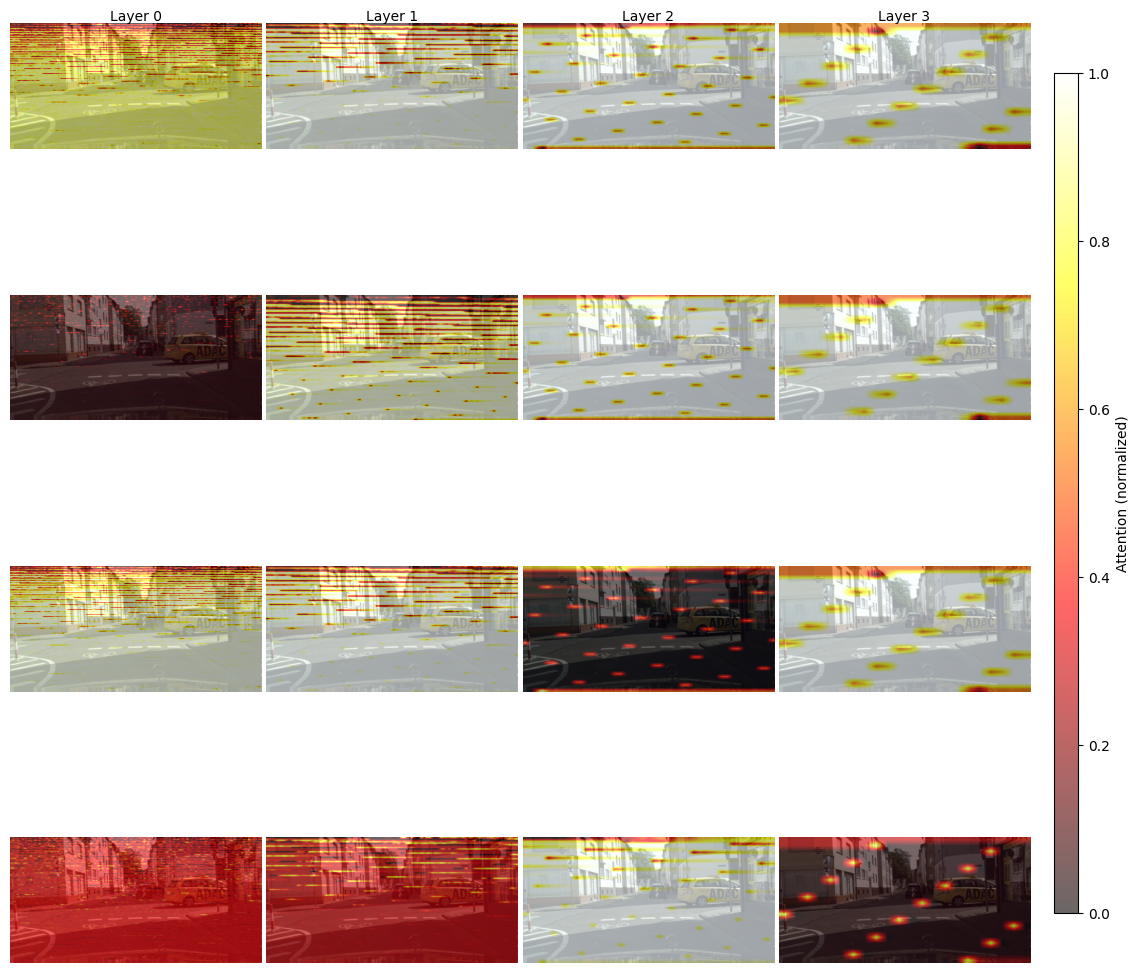

In [8]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

def visualize_heads_layers_grid(
    model, image, DEVICE, layer_indices=None,
    upsample=True, alpha=0.6, gamma=1.0, save_path=None
):
    """
    Zeigt ein 4x4 Grid:
      - Zeilen: Heads (0–3)
      - Spalten: Layers (layer_indices)
    für EIN Bild.
    """
    model.eval()
    img = image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits, attentions = model(img, return_attention=True)

    if layer_indices is None:
        layer_indices = list(range(4))  # default: erste 4 Layers

    num_heads = 4
    num_layers = len(layer_indices)

    img_vis = img[0].permute(1,2,0).cpu().numpy()
    img_vis = img_vis * 0.225 + 0.45
    img_vis = img_vis.clip(0,1)
    H_img, W_img = img_vis.shape[:2]

    fig, axes = plt.subplots(num_heads, num_layers,
                             figsize=(3*num_layers, 3*num_heads))

    for h in range(num_heads):
        for c, l_idx in enumerate(layer_indices):
            ax = axes[h, c]

            attn_layer = attentions[l_idx][0]   # [heads, tokens, tokens]
            attn_cls = attn_layer[h][0, 1:]     # CLS -> Patches (ein Head)

            side_len = int(attn_cls.shape[0] ** 0.5)
            attn_map = attn_cls[:side_len**2].reshape(side_len, side_len).unsqueeze(0).unsqueeze(0)

            if upsample:
                attn_map = F.interpolate(
                    attn_map, size=(H_img, W_img),
                    mode='bilinear', align_corners=False
                ).squeeze().cpu().numpy()

            # Normalisieren und Gamma
            attn_map = attn_map - attn_map.min()
            if attn_map.max() > 0:
                attn_map = attn_map / attn_map.max()
            attn_map = attn_map ** gamma

            ax.imshow(img_vis)
            im = ax.imshow(attn_map, cmap='hot', alpha=alpha)
            ax.axis('off')

            if h == 0:
                ax.set_title(f'Layer {l_idx}', fontsize=10, pad=2)
            if c == 0:
                ax.set_ylabel(f'Head {h}', fontsize=10)

    # Gemeinsame Farblegende
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Attention (normalized)')

    plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0.05,
                        right=0.9, top=0.95, bottom=0.05)

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure gespeichert unter: {save_path}")

    plt.show()


visualize_heads_layers_grid(
    model,
    images_list[0],
    device,
    layer_indices=[0, 1, 2, 3],   # vier Layers
    save_path="heads_layers_4x4.png"
)

In [ ]:
def visualize_hybrid_attention_more_specific(
    model, images, DEVICE, upsample=True, alpha=0.6, save_path=None, gamma=1.0
):
    """
    Visualisiert Cross-Attention pro Bild & Layer, mittelt nur über Heads.
    So bleiben Unterschiede zwischen Bildern klarer sichtbar.
    """
    model.eval()
    num_layers = None
    num_images = images.shape[0]

    fig, axes = None, None

    for i in range(num_images):
        img = images[i].unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            logits, attentions = model(img, return_attention=True)

        if num_layers is None:
            num_layers = len(attentions)
            fig, axes = plt.subplots(num_images, num_layers, figsize=(3*num_layers, 1.5*num_images))
            if num_images == 1:
                axes = [axes]
            if num_layers == 1:
                axes = [[ax] for ax in axes]

        img_vis = img[0].permute(1, 2, 0).cpu().numpy()
        img_vis = img_vis * 0.225 + 0.45
        img_vis = img_vis.clip(0, 1)
        H_img, W_img = img_vis.shape[:2]

        for l_idx in range(num_layers):
            ax = axes[i][l_idx]

            # [Heads, Queries, Keys]
            attn_layer = attentions[l_idx][0]  

            # Nur über Heads mitteln, Queries behalten
            attn_map = attn_layer.mean(0).cpu()  # [Queries, Keys]

            # Für Cross-Attention nehmen wir die Query-Seite (RGB)
            side_len = int(attn_map.shape[0] ** 0.5)
            attn_map_2d = attn_map[:side_len**2].mean(1).reshape(side_len, side_len).unsqueeze(0).unsqueeze(0)

            if upsample:
                attn_map_2d = F.interpolate(
                    attn_map_2d, size=(H_img, W_img), mode="bilinear", align_corners=False
                ).squeeze().numpy()

            # Normalisierung
            attn_map_2d = attn_map_2d - attn_map_2d.min()
            if attn_map_2d.max() > 0:
                attn_map_2d = attn_map_2d / attn_map_2d.max()
            attn_map_2d = attn_map_2d ** gamma

            ax.imshow(img_vis)
            im = ax.imshow(attn_map_2d, cmap="hot", alpha=alpha)
            ax.axis("off")
            if i == 0:
                ax.set_title(f"L{l_idx}", fontsize=9, pad=1)

        del img, logits, attentions
        torch.cuda.empty_cache()

    # Gemeinsame Farblegende
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="Attention (normalized)")

    plt.subplots_adjust(wspace=0.02, hspace=0, left=0.05, right=0.9, top=0.95, bottom=0.05)

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure gespeichert unter: {save_path}")

    plt.show()

In [13]:
loader_iter = iter(target_loader)
images_list = []

while len(images_list) < 3:
    images, _ = next(loader_iter)   # Batch holen
    images_list.extend([img for img in images])  # Alle Bilder aus dem Batch hinzufügen

images_list = images_list[:3]  # auf exakt 3 Bilder kürzen
images = torch.stack(images_list)



In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

def visualize_hybrid_attention_multi_globalnorm(
    model, images, DEVICE, upsample=True, alpha=0.6, save_path=None, gamma=1.0
):
    """
    Visualisiert Cross-Attention kompakt für mehrere Bilder.
    -> Globale Normalisierung aller Maps auf [0, 1]
    -> Immer Subplots für jedes Bild + jeden Layer
    """
    model.eval()
    num_layers = None
    num_images = images.shape[0]

    raw_maps = []   # Alle Maps sammeln
    img_cache = []  # Originalbilder speichern
    attn_shapes = []  

    with torch.no_grad():
        for i in range(num_images):
            img = images[i].unsqueeze(0).to(DEVICE)
            logits, attentions = model(img, return_attention=True)
            
            if num_layers is None:
                num_layers = len(attentions)

            # Inputbild für Overlay vorbereiten
            img_vis = img[0].permute(1,2,0).cpu().numpy()
            img_vis = img_vis * 0.225 + 0.45   # dein Normierungsschema
            img_vis = img_vis.clip(0,1)
            H_img, W_img = img_vis.shape[:2]
            img_cache.append(img_vis)

            # Attention pro Layer einsammeln
            for l_idx in range(num_layers):
                attn_layer = attentions[l_idx][0]        # (heads, N_query, N_key)
                attn_map = attn_layer.mean(0).mean(0)    # Mittel über Heads + Queries
                side_len = int(attn_map.shape[0]**0.5)
                attn_map_2d = attn_map[:side_len**2].reshape(side_len, side_len).unsqueeze(0).unsqueeze(0)

                if upsample:
                    attn_map_2d = F.interpolate(
                        attn_map_2d, size=(H_img, W_img), mode='bilinear', align_corners=False
                    )
                raw_maps.append(attn_map_2d.squeeze(0).squeeze(0).cpu())
                attn_shapes.append((i, l_idx))

            del img, logits, attentions
            torch.cuda.empty_cache()

    # --- Globale Normalisierung auf [0, 1] ---
    all_maps_tensor = torch.stack(raw_maps)   # (N_total, H, W)
    min_val, max_val = all_maps_tensor.min(), all_maps_tensor.max()
    all_maps_norm = (all_maps_tensor - min_val) / (max_val - min_val + 1e-8)
    all_maps_norm = all_maps_norm**gamma   # gamma-Korrektur optional

    # --- Plotten ---
    fig, axes = plt.subplots(num_images, num_layers, figsize=(3*num_layers, 1.5*num_images))

    # Immer sicherstellen, dass axes 2D ist
    if num_images == 1:
        axes = np.expand_dims(axes, axis=0)   # (1, num_layers)
    if num_layers == 1:
        axes = np.expand_dims(axes, axis=1)   # (num_images, 1)

    for idx, (i, l_idx) in enumerate(attn_shapes):
        ax = axes[i][l_idx]
        ax.imshow(img_cache[i])
        im = ax.imshow(all_maps_norm[idx].numpy(), cmap='hot', alpha=alpha, vmin=0, vmax=1)
        ax.axis('off')
        if i == 0:
            ax.set_title(f"L{l_idx}", fontsize=9, pad=1)

    # Gemeinsame Farblegende mit fester [0,1]-Skala
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Attention (0–1, global)')

    plt.subplots_adjust(wspace=0.02, hspace=0, left=0.05, right=0.9, top=0.95, bottom=0.05)

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure gespeichert unter: {save_path}")

    plt.show()

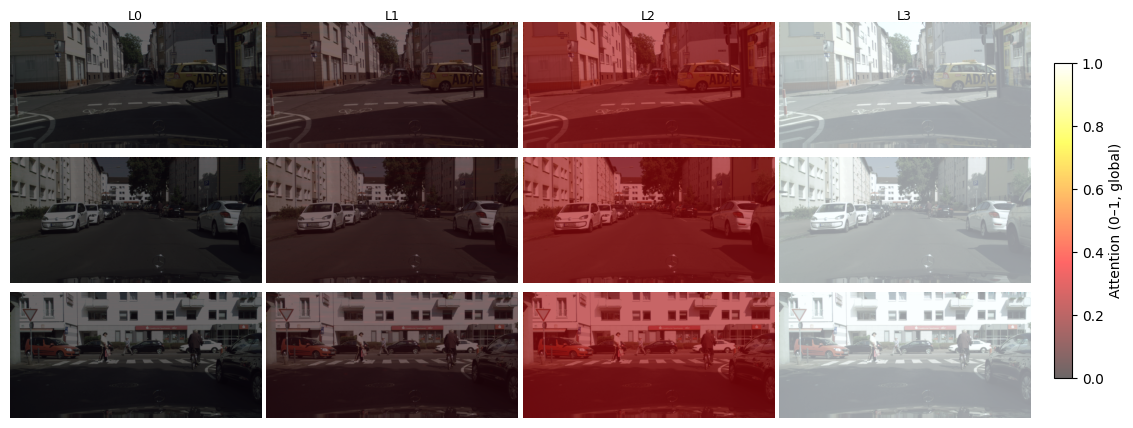

In [15]:
visualize_hybrid_attention_multi_globalnorm(model, images, device)

Figure gespeichert unter: attn_strength.png


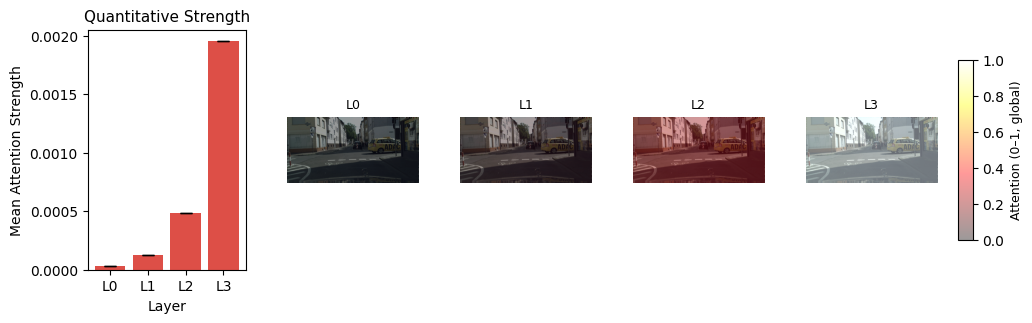

In [24]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def visualize_attention_strength_with_example(
    model, images, DEVICE, example_idx=0, upsample=True,
    save_path=None, alpha=0.4, gamma=1.0
):
    """
    Links: Balkendiagramm (Mittel ± Std) der Cross-Attention-Stärke pro Layer.
    Rechts: Beispielbild mit Heatmaps pro Layer (globale Norm, gemeinsame Skala).
    """
    model.eval()
    num_layers = None
    attn_means = []

    # --- 1) Werte über alle Bilder sammeln ---
    with torch.no_grad():
        for i in range(images.shape[0]):
            img = images[i].unsqueeze(0).to(DEVICE)
            logits, attentions = model(img, return_attention=True)

            if num_layers is None:
                num_layers = len(attentions)
                attn_means = [[] for _ in range(num_layers)]

            for l_idx in range(num_layers):
                attn_layer = attentions[l_idx][0]  # (heads, N_query, N_key)
                mean_val = attn_layer.mean().item()
                attn_means[l_idx].append(mean_val)

            del img, logits, attentions
            torch.cuda.empty_cache()

    # Mittel & Std pro Layer
    mean_vals = [np.mean(vals) for vals in attn_means]
    std_vals = [np.std(vals) for vals in attn_means]

    # --- 2) Figur mit Balkendiagramm + Heatmaps ---
    fig, axes = plt.subplots(
        1, num_layers+1, figsize=(2*(num_layers+1), 3),
        gridspec_kw={"width_ratios": [1.2] + [1]*num_layers}
    )

    # Linker Plot: Balkendiagramm
    ax_bar = axes[0]
    layers = np.arange(num_layers)
    ax_bar.bar(layers, mean_vals, yerr=std_vals, capsize=4,
               color="#d73027", alpha=0.85)
    ax_bar.set_ylabel("Mean Attention Strength", fontsize=10)
    ax_bar.set_xlabel("Layer", fontsize=10)
    ax_bar.set_xticks(layers)
    ax_bar.set_xticklabels([f"L{i}" for i in layers])
    ax_bar.set_title("Quantitative Strength", fontsize=11)

    # --- 3) Beispiel Heatmaps (ein Bild) ---
    img = images[example_idx].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits, attentions = model(img, return_attention=True)

    img_vis = img[0].permute(1,2,0).cpu().numpy()
    img_vis = img_vis * 0.225 + 0.45  # deine Normierung
    img_vis = img_vis.clip(0,1)
    H_img, W_img = img_vis.shape[:2]

    # Heatmaps sammeln
    heatmaps = []
    for l_idx in range(num_layers):
        attn_layer = attentions[l_idx][0]
        attn_map = attn_layer.mean(0).mean(0)
        side_len = int(attn_map.shape[0]**0.5)
        attn_map_2d = attn_map[:side_len**2].reshape(side_len, side_len).unsqueeze(0).unsqueeze(0)
        if upsample:
            attn_map_2d = F.interpolate(
                attn_map_2d, size=(H_img, W_img), mode='bilinear', align_corners=False
            )
        heatmaps.append(attn_map_2d.squeeze().cpu().numpy())

    # Globale Normalisierung über alle Heatmaps
    all_vals = np.concatenate([hm.flatten() for hm in heatmaps])
    vmin, vmax = all_vals.min(), all_vals.max()
    heatmaps = [(hm - vmin) / (vmax - vmin + 1e-8) for hm in heatmaps]

    # Plot Heatmaps
    ims = []
    for l_idx in range(num_layers):
        ax = axes[l_idx+1]
        ax.imshow(img_vis)
        im = ax.imshow(heatmaps[l_idx]**gamma, cmap="hot", alpha=alpha, vmin=0, vmax=1)
        ims.append(im)
        ax.axis("off")
        ax.set_title(f"L{l_idx}", fontsize=9)

    # Gemeinsame Colorbar
    cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
    cbar = fig.colorbar(ims[0], cax=cbar_ax)
    cbar.set_label("Attention (0–1, global)", fontsize=9)

    plt.subplots_adjust(wspace=0.3, left=0.05, right=0.9, top=0.9, bottom=0.1)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure gespeichert unter: {save_path}")
    plt.show()

    return mean_vals, std_vals


images_tensor = torch.stack(images_list[:3])  # z.B. 3 Bilder
mean_vals, std_vals = visualize_attention_strength_with_example(
    model, images_tensor, device, save_path="attn_strength.png"
)

Figure gespeichert unter: attn_strength_with_example.png


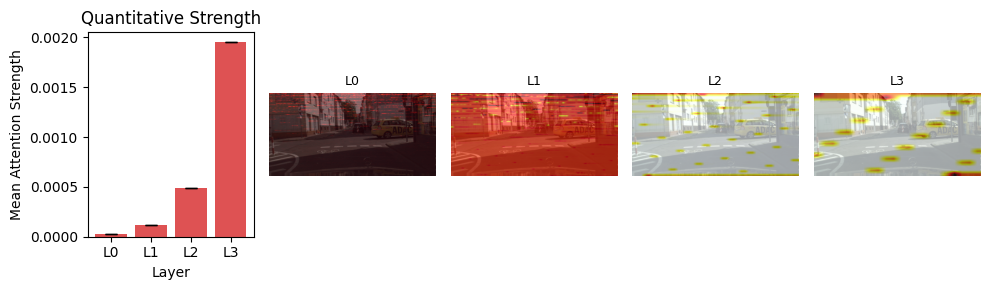

In [20]:


images_tensor = torch.stack(images_list[:10])  # mehrere Bilder sammeln
mean_vals, std_vals = visualize_attention_strength_with_example(
    model, images_tensor, device, example_idx=0, save_path="attn_strength_with_example.png"
)

In [38]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch

def compute_attention_stats(model, dataloader, DEVICE, max_batches=10):
    """
    Berechnet Mean ± Std der Attention-Stärke pro Layer für max_batches Batches.
    """
    model.eval()
    num_layers = None
    attn_means = []

    with torch.no_grad():
        for b_idx, (images, _) in enumerate(tqdm(dataloader, desc="Computing attention stats", leave=False)):
            images = images.to(DEVICE)
            for i in range(images.shape[0]):
                img = images[i].unsqueeze(0)
                logits, attentions = model(img, return_attention=True)

                if num_layers is None:
                    num_layers = len(attentions)
                    attn_means = [[] for _ in range(num_layers)]

                for l_idx in range(num_layers):
                    attn_layer = attentions[l_idx][0]
                    mean_val = attn_layer.mean().item()
                    attn_means[l_idx].append(mean_val)

            if (b_idx + 1) >= max_batches:
                break

    mean_vals = [np.mean(vals) for vals in attn_means]
    std_vals  = [np.std(vals) for vals in attn_means]
    return mean_vals, std_vals


def compare_checkpoints_on_datasets(model_class, cp_paths, modes, dataloaders, dataset_names, DEVICE, max_batches=10, save_path=None):
    """
    Vergleicht mehrere Checkpoints/Modalitäten auf mehreren Datasets.
    Rows = Datasets
    Cols = Checkpoints/Modalitäten
    """
    num_datasets = len(dataloaders)
    num_cps = len(cp_paths)

    # --- Erst alle Werte berechnen ---
    all_stats = {d: {} for d in dataset_names}
    dataset_max = {}

    for (loader, dset_name) in zip(dataloaders, dataset_names):
        for (cp_path, mode) in zip(cp_paths, modes):
            print(f"=== {dset_name} | {mode} ===")
            model = model_class(mode=mode).to(DEVICE)
            checkpoint = torch.load(cp_path, map_location=DEVICE)
            model.load_state_dict(checkpoint['model_state_dict'])
            mean_vals, std_vals = compute_attention_stats(model, loader, DEVICE, max_batches=max_batches)
            all_stats[dset_name][mode] = (mean_vals, std_vals)

        # Skala pro Dataset
        dataset_max[dset_name] = max([
            max(np.array(m) + np.array(s)) 
            for m, s in all_stats[dset_name].values()
        ])

    # --- Plotten ---
    fig, axes = plt.subplots(num_datasets, num_cps, figsize=(4*num_cps, 3*num_datasets))

    if num_datasets == 1: axes = np.expand_dims(axes, 0)
    if num_cps == 1: axes = np.expand_dims(axes, 1)

    for row, dset_name in enumerate(dataset_names):
        for col, mode in enumerate(modes):
            ax = axes[row][col]
            mean_vals, std_vals = all_stats[dset_name][mode]
            layers = np.arange(len(mean_vals))
            ax.bar(layers, mean_vals, yerr=std_vals, capsize=4, color="#d73027", alpha=0.85)
            ax.set_xticks(layers)
            ax.set_xticklabels([f"L{i}" for i in layers])
            ax.set_ylim(0, dataset_max[dset_name] * 1.05)
            if row == num_datasets-1:
                ax.set_xlabel("Layer")
            if col == 0:
                ax.set_ylabel(f"{dset_name}\nMean Attention Strength")
            ax.set_title(mode.upper())

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure gespeichert unter: {save_path}")
    plt.show()

Use cityscapes as the target dataset
Use bdd as the target dataset
=== Cityscapes | edge ===


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


=== Cityscapes | dct ===


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


=== Cityscapes | hsv ===


...

=== BDD | dct ===


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


=== BDD | hsv ===


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Figure gespeichert unter: compare_modalities.png


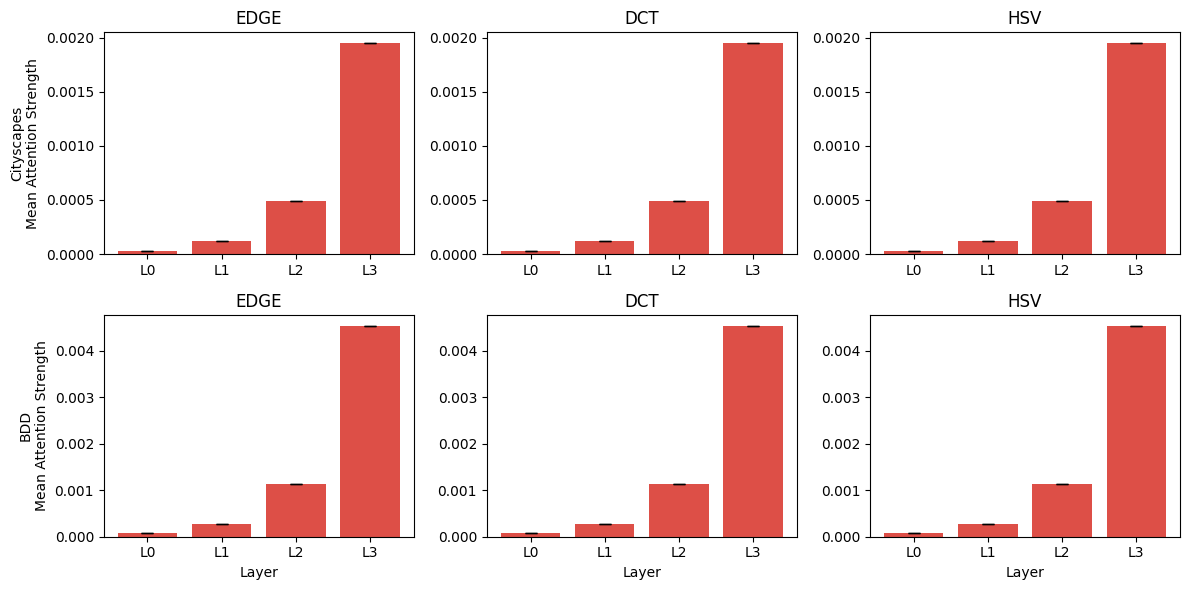

In [39]:
cp_paths = [
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_edges_no_amp.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_dct_no_amp.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_hsv_no_amp.pth'
]


modes = ['edge', 'dct', 'hsv']

cs_target_loader = utils.get_dataloader_from_dataset(
    './cityscapes', 'cityscapes', 'val', batch_size=1, shuffle=False
)
bdd_target_loader = utils.get_dataloader_from_dataset(
    './bdd', 'bdd', 'val', batch_size=1, shuffle=False
)

compare_checkpoints_on_datasets(
    SegformerCrossAttentionWrapper,
    cp_paths,
    modes,
    [cs_target_loader, bdd_target_loader],
    ["Cityscapes", "BDD"],
    DEVICE=device,
    max_batches=10,
    save_path="compare_modalities.png"
)

In [40]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch

def compute_attention_stats(model, dataloader, DEVICE, max_batches=10):
    """
    Berechnet verschiedene Attention-Statistiken (Mean, Max, Var) pro Layer.
    """
    model.eval()
    num_layers = None
    attn_means, attn_max, attn_vars = [], [], []

    with torch.no_grad():
        for b_idx, (images, _) in enumerate(tqdm(dataloader, desc="Computing attention stats", leave=False)):
            images = images.to(DEVICE)
            for i in range(images.shape[0]):
                img = images[i].unsqueeze(0)
                logits, attentions = model(img, return_attention=True)

                if num_layers is None:
                    num_layers = len(attentions)
                    attn_means = [[] for _ in range(num_layers)]
                    attn_max   = [[] for _ in range(num_layers)]
                    attn_vars  = [[] for _ in range(num_layers)]

                for l_idx in range(num_layers):
                    attn_layer = attentions[l_idx][0]  # Shape: Heads x N x N
                    attn_means[l_idx].append(attn_layer.mean().item())
                    attn_max[l_idx].append(attn_layer.max().item())
                    attn_vars[l_idx].append(attn_layer.var().item())

            if (b_idx + 1) >= max_batches:
                break

    mean_vals = [np.mean(v) for v in attn_means]
    max_vals  = [np.mean(v) for v in attn_max]
    var_vals  = [np.mean(v) for v in attn_vars]

    return mean_vals, max_vals, var_vals


def compare_checkpoints_on_datasets(model_class, experiments, dataloaders, dataset_names, DEVICE, max_batches=10, save_path=None):
    """
    Vergleicht mehrere (Checkpoint, Mode)-Paare auf mehreren Datasets.
    Rows = Datasets
    Cols = Experiments (Checkpoints/Modalitäten)
    Zeigt je Plot Balkendiagramme für Mean, Max und Var pro Layer.
    """
    num_datasets = len(dataloaders)
    num_exps = len(experiments)

    # --- Erst alle Werte berechnen ---
    all_stats = {d: {} for d in dataset_names}
    dataset_max = {}

    for (loader, dset_name) in zip(dataloaders, dataset_names):
        for (cp_path, mode) in experiments:
            print(f"=== {dset_name} | {mode} ===")
            model = model_class(mode=mode).to(DEVICE)
            checkpoint = torch.load(cp_path, map_location=DEVICE)
            model.load_state_dict(checkpoint['model_state_dict'])
            mean_vals, max_vals, var_vals = compute_attention_stats(model, loader, DEVICE, max_batches=max_batches)
            all_stats[dset_name][mode] = (mean_vals, max_vals, var_vals)

        # Skala pro Dataset nur für Mean
        dataset_max[dset_name] = max([
            max(v[0]) for v in all_stats[dset_name].values()
        ])

    # --- Plotten ---
    fig, axes = plt.subplots(num_datasets, num_exps, figsize=(5*num_exps, 3*num_datasets))

    if num_datasets == 1: axes = np.expand_dims(axes, 0)
    if num_exps == 1: axes = np.expand_dims(axes, 1)

    for row, dset_name in enumerate(dataset_names):
        for col, (cp_path, mode) in enumerate(experiments):
            ax = axes[row][col]
            mean_vals, max_vals, var_vals = all_stats[dset_name][mode]
            layers = np.arange(len(mean_vals))

            width = 0.25
            ax.bar(layers - width, mean_vals, width=width, label="Mean", alpha=0.8)
            ax.bar(layers,        max_vals,  width=width, label="Max",  alpha=0.8)
            ax.bar(layers + width, var_vals, width=width, label="Var",  alpha=0.8)

            ax.set_xticks(layers)
            ax.set_xticklabels([f"L{i}" for i in layers])
            ax.set_ylim(0, dataset_max[dset_name] * 1.2)  # Skala auf Mean abgestimmt
            if row == num_datasets-1:
                ax.set_xlabel("Layer")
            if col == 0:
                ax.set_ylabel(f"{dset_name}\nAttention Stats")
            ax.set_title(mode.upper())

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure gespeichert unter: {save_path}")
    plt.show()

Use cityscapes as the target dataset
Use bdd as the target dataset
=== Cityscapes | edge ===


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


=== Cityscapes | fft ===


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


=== Cityscapes | dct ===


...

=== BDD | dct ===


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


=== BDD | hsv ===


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Figure gespeichert unter: compare_modalities_stats.png


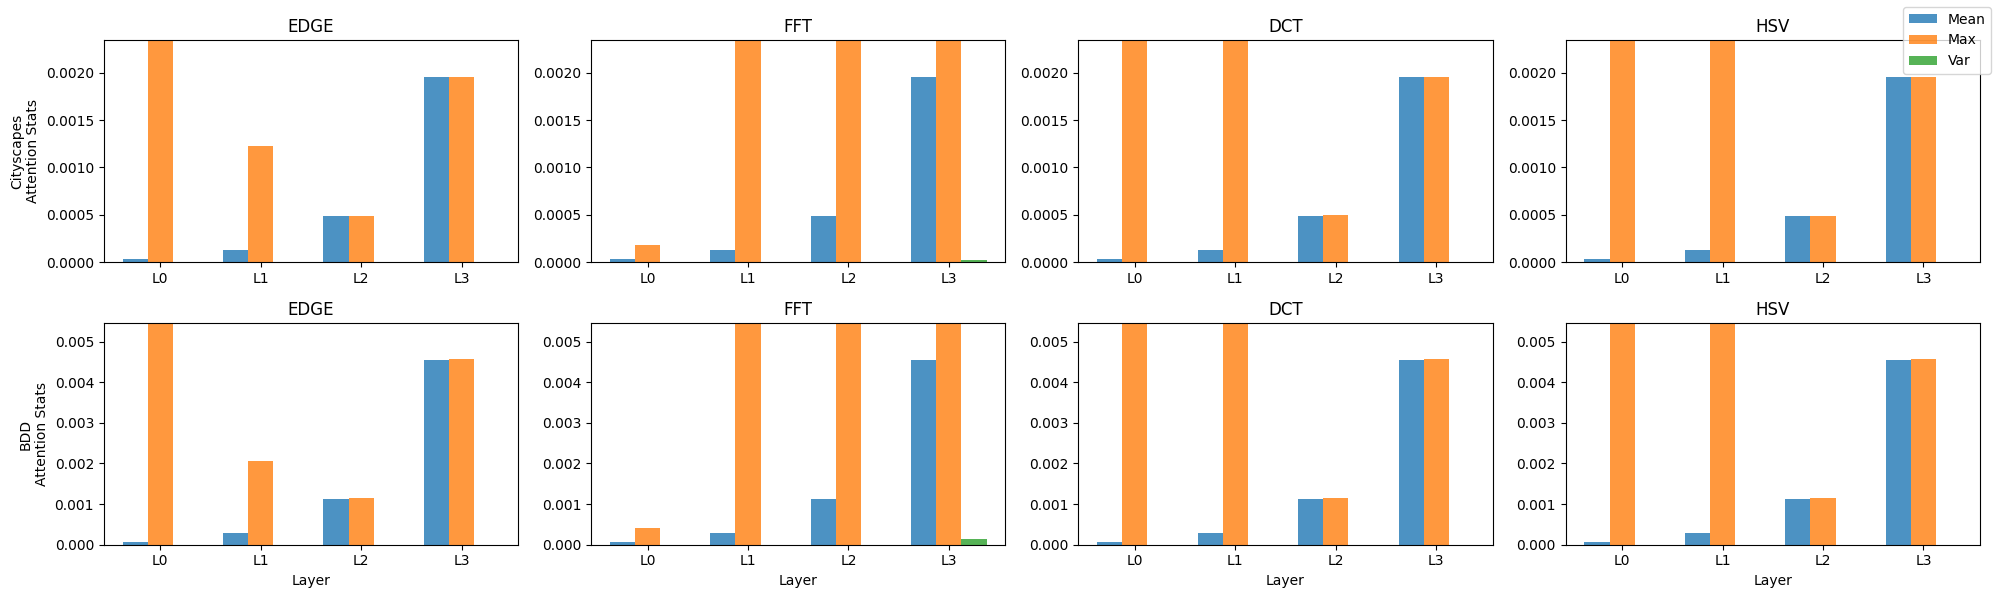

In [46]:
cp_paths = [
    ('./checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_edges_no_amp.pth', 'edge'),
    ('./checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_fft_no_amp.pth', 'fft'),
    ('./checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_dct_no_amp.pth', 'dct'),
    ('./checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_hsv_no_amp.pth', 'hsv')
]

cs_target_loader = utils.get_dataloader_from_dataset(
    './cityscapes', 'cityscapes', 'val', batch_size=1, shuffle=False
)
bdd_target_loader = utils.get_dataloader_from_dataset(
    './bdd', 'bdd', 'val', batch_size=1, shuffle=False
)

compare_checkpoints_on_datasets(
    SegformerCrossAttentionWrapper,
    cp_paths,
    [cs_target_loader, bdd_target_loader],
    ["Cityscapes", "BDD"],
    DEVICE=device,
    max_batches=10,
    save_path="compare_modalities_stats.png"
)



Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head.batch_norm.bi

Figure gespeichert unter: gating_grid.png


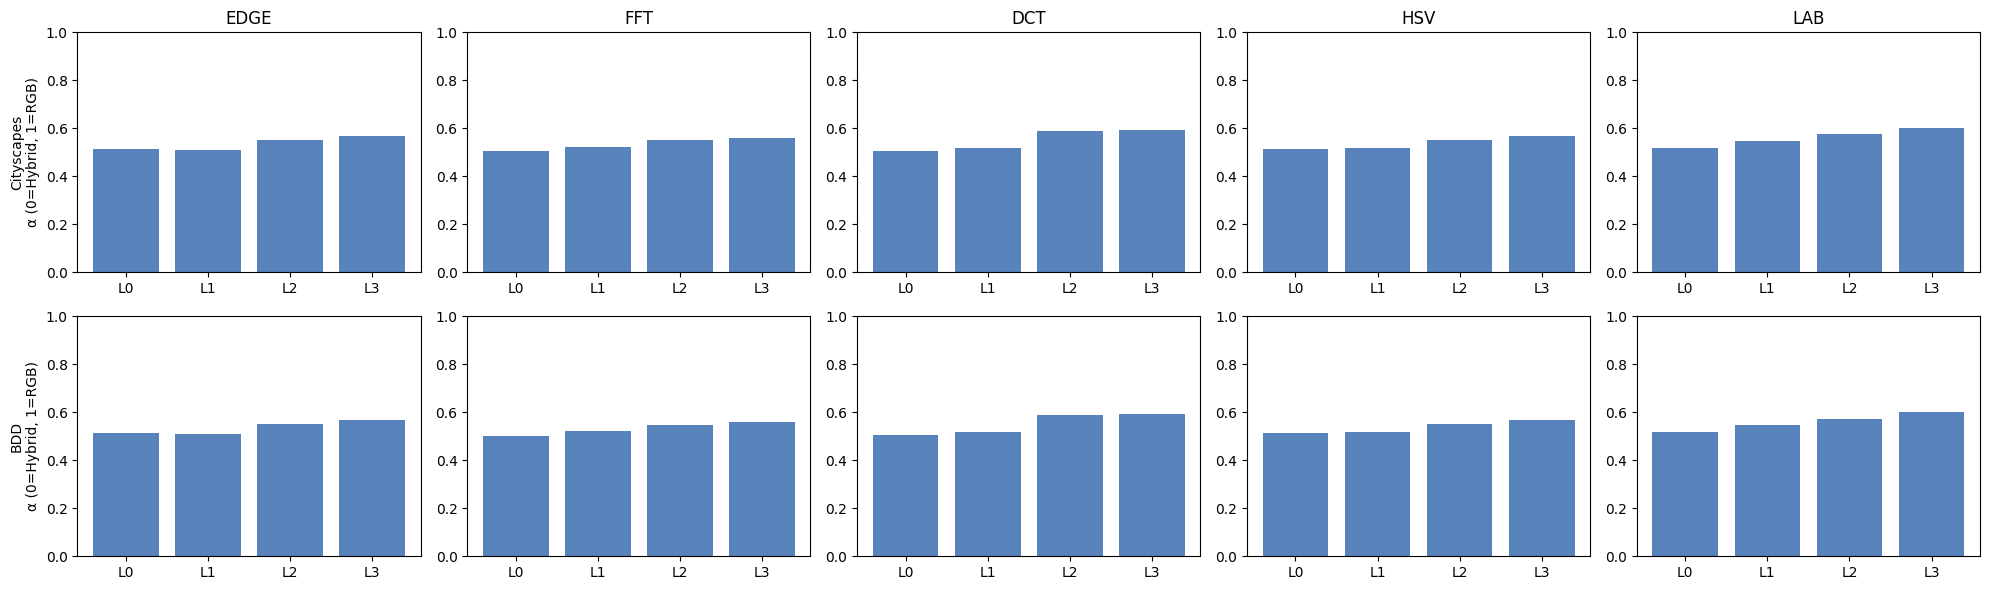

In [61]:
def collect_gating_weights(model_class, cp_paths, modes, device):
    results = {}
    for cp_path, mode in zip(cp_paths, modes):
        model = model_class(mode=mode, num_classes=16).to(device)
        checkpoint = torch.load(cp_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'], strict=False)
        gating_vals = [torch.sigmoid(w).item() for w in model.gating_weights]
        results[mode] = gating_vals
    return results


def plot_gating_grid(results, datasets, modes, save_path=None):
    num_datasets = len(datasets)
    num_modes    = len(modes)
    fig, axes = plt.subplots(num_datasets, num_modes, figsize=(4*num_modes, 3*num_datasets))

    if num_datasets == 1:
        axes = np.expand_dims(axes, 0)
    if num_modes == 1:
        axes = np.expand_dims(axes, 1)

    for d_idx, dataset in enumerate(datasets):
        for m_idx, mode in enumerate(modes):
            vals = results[mode]
            x = np.arange(len(vals))
            ax = axes[d_idx][m_idx]
            ax.bar(x, vals, color="#4575b4", alpha=0.9)
            ax.set_xticks(x)
            ax.set_xticklabels([f"L{i}" for i in x])
            ax.set_ylim(0, 1)
            if d_idx == 0:
                ax.set_title(mode.upper())
            if m_idx == 0:
                ax.set_ylabel(f"{dataset}\nα (0=Hybrid, 1=RGB)")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure gespeichert unter: {save_path}")
    plt.show()


# ---------- Nutzung ----------
cp_paths = [
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_edges_conv_v2.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_fft_gating_conv_v2.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_dct_gating_conv_v2.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_hsv_gating_conv_v2.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_rgb_and_lab_conv_v2.pth',
]
modes = ['edge', 'fft', 'dct', 'hsv', 'lab']

results = collect_gating_weights(SegformerCrossAttentionWrapperV2, cp_paths, modes, device)

plot_gating_grid(results, ["Cityscapes", "BDD"], modes, save_path="gating_grid.png")

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head.batch_norm.bi

Linienplot gespeichert unter: gating_lines.png


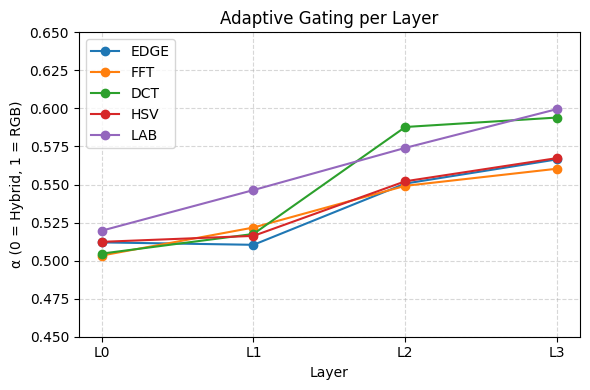

In [63]:
def collect_gating_values(model_class, cp_paths, modes, device):
    results = {}
    for cp_path, mode in zip(cp_paths, modes):
        model = model_class(mode=mode, num_classes=16).to(device)
        checkpoint = torch.load(cp_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'], strict=False)
        gating_vals = [torch.sigmoid(w).item() for w in model.gating_weights]
        results[mode] = gating_vals
    return results


def plot_gating_lines(results, save_path=None):
    plt.figure(figsize=(6,4))
    layers = [f"L{i}" for i in range(len(next(iter(results.values()))))]

    for mode, vals in results.items():
        plt.plot(layers, vals, marker="o", label=mode.upper())

    plt.ylim(0.45, 0.65)
    plt.xlabel("Layer")
    plt.ylabel("α (0 = Hybrid, 1 = RGB)")
    plt.title("Adaptive Gating per Layer")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Linienplot gespeichert unter: {save_path}")
    plt.show()


# ----------- Nutzung -----------
cp_paths = [
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_edges_conv_v2.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_fft_gating_conv_v2.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_dct_gating_conv_v2.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_hsv_gating_conv_v2.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_rgb_and_lab_conv_v2.pth',
]
modes = ['edge', 'fft', 'dct', 'hsv', 'lab']

results = collect_gating_values(SegformerCrossAttentionWrapperV2, cp_paths, modes, device)
plot_gating_lines(results, save_path="gating_lines.png")

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head.batch_norm.bi

Figure gespeichert unter: adaptive_gating_combo.png


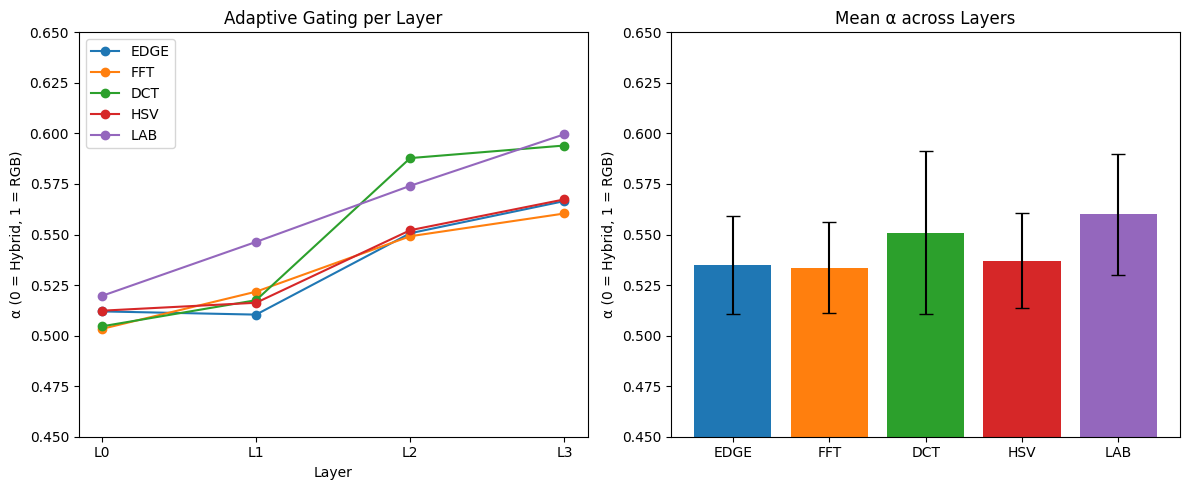

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def plot_adaptive_gating(modes, cp_paths, WrapperClass, device="cuda", save_path="adaptive_gating_combo.png"):
    all_alphas = {}
    
    # Farben aus Matplotlib nehmen (konsistent)
    colors = plt.cm.tab10.colors  

    for mode, cp_path in zip(modes, cp_paths):
        model = WrapperClass(mode=mode).to(device)
        checkpoint = torch.load(cp_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"], strict=False)

        alphas = [torch.sigmoid(param).item() for param in model.gating_weights]
        all_alphas[mode.upper()] = alphas

    layers = [f"L{i}" for i in range(len(next(iter(all_alphas.values()))))]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Linienplot ---
    for idx, (mode, alphas) in enumerate(all_alphas.items()):
        axes[0].plot(layers, alphas, marker="o", label=mode, color=colors[idx])

    axes[0].set_ylim(0.45, 0.65)
    axes[0].set_title("Adaptive Gating per Layer")
    axes[0].set_ylabel("α (0 = Hybrid, 1 = RGB)")
    axes[0].set_xlabel("Layer")
    axes[0].legend()

    # --- Balkendiagramm ---
    means = [np.mean(alphas) for alphas in all_alphas.values()]
    stds  = [np.std(alphas) for alphas in all_alphas.values()]

    for idx, (mode, mean, std) in enumerate(zip(all_alphas.keys(), means, stds)):
        axes[1].bar(mode, mean, yerr=std, capsize=5, color=colors[idx])

    axes[1].set_ylim(0.45, 0.65)
    axes[1].set_title("Mean α across Layers")
    axes[1].set_ylabel("α (0 = Hybrid, 1 = RGB)")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Figure gespeichert unter: {save_path}")
    plt.show()


# ----------- checkpoints -----------
cp_paths = [
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_edges_conv_v2.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_fft_gating_conv_v2.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_dct_gating_conv_v2.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_hsv_gating_conv_v2.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_rgb_and_lab_conv_v2.pth',
]

modes = ['edge', 'fft', 'dct', 'hsv', 'lab']

# Falls dein Wrapper anders heißt, hier anpassen
plot_adaptive_gating(
    modes, 
    cp_paths, 
    WrapperClass=SegformerCrossAttentionWrapperV2, 
    device=device, 
    save_path="adaptive_gating_combo.png"
)

In [ ]:
# --- Imports ---
from transformers import SegformerForSemanticSegmentation
from segformer_crossattention_wrapper import *
from segformer_crossattention_wrapperv2 import *
from utils import *
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
import torch

# --- Device ---
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


def plot_adaptive_gating(modes, cp_paths, WrapperClass, device="cuda", save_path="adaptive_gating_combo.png"):
    all_alphas = {}
    colors = plt.cm.tab10.colors  # konsistente Farben

    for mode, cp_path in zip(modes, cp_paths):
        model = WrapperClass(mode=mode).to(device)
        checkpoint = torch.load(cp_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"], strict=False)

        # Nur einzelne α-Werte pro Layer
        alphas = [torch.sigmoid(param).item() for param in model.gating_weights]
        all_alphas[mode.upper()] = alphas

        print(alphas)
        break

    layers = [f"L{i}" for i in range(len(next(iter(all_alphas.values()))))]

    # --- Linienplot ---
    plt.figure(figsize=(8, 5))
    for idx, (mode, alphas) in enumerate(all_alphas.items()):
        plt.plot(layers, alphas, marker="o", label=mode, color=colors[idx])

    plt.ylim(0.45, 0.65)
    plt.title("Adaptive Gating per Layer")
    plt.ylabel("α (0 = Hybrid, 1 = RGB)")
    plt.xlabel("Layer")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Figure gespeichert unter: {save_path}")
    plt.show()


# ----------- Checkpoints & Modi -----------
cp_paths = [
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_edges_conv_v2.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_fft_gating_conv_v2.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_dct_gating_conv_v2.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_crossattention_rgb_and_hsv_gating_conv_v2.pth',
    './checkpoints/synthia_to_cs_and_bdd_lr1e5_and_lr1e4_rgb_and_lab_conv_v2.pth',
]

modes = ['edge', 'fft', 'dct', 'hsv', 'lab']

# --- Aufruf ---
plot_adaptive_gating(
    modes,
    cp_paths,
    WrapperClass=SegformerCrossAttentionWrapperV2,
    device=device,
    save_path="adaptive_gating_combo.png"
)

In [ ]:
!pip install 


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip
error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at